# Тональности постов Twitter

Даны два датасета с положительными и отрицательными постами Twitter, сделанных на русском языке. Требуется создать модель для определения тональности постов.

# 1. Определение необходимых полей и создания структуры набора данных.

- Определить атрибуты, сильнее всего влияющие на тональность текста, и отобрать только их для дальнейшего обучения модели.
- Обосновать, какие именно дополнительные атрибуты добавлены в набор и почему.
- Объяснить причины исключения определённых данных из исходного набора документов.

### Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Анализ исходных данных

Загружаем наборы данных в переменные.

In [4]:
positive_posts = pd.read_csv('pos.csv', sep=';', quotechar='"', header=None)
negative_posts = pd.read_csv('neg.csv', sep=';', quotechar='"', header=None)

Посмотрим на образцы записей:

In [5]:
positive_posts.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
1,408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
2,408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0
3,408906695356973056,1386325927,ikonnikova_21,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,0,1,0,1549,19,17,0
4,408906761416867842,1386325943,JumpyAlex,@irina_dyshkant Вот что значит страшилка :D\nН...,1,0,0,0,597,16,23,1


In [6]:
negative_posts.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


Изучив каждый атрибут в датасетах можно сделать некий вывод об их примерном содержании:
- 0 - **id поста**
- 1 - **возможно id пользователя**
- 2 - **имя пользователя**
- 3 - **текст поста** - **основной носитель тональности**
- 4 - исходя из значений в двух датасетах в этом атрибуте содержится числовое **значение тональности** (1 - позитивный тон, -1 - негативный тон) - **целевая переменная**
- 5-11 - **числовые метаданные**, которые тяжело правильно интерпретировать. Скорее всего статистика постов.

Для будущего обучения нам понадобятся только **текст поста** и **значение тональности**. Остальные же атрибуты не играют большой роли для этой задачи, так как они:

1. Неинтерпретируемы.
2. Отсутствие прямой связи с тональностью.
3. Риск переобучения, особенно для будущего парсинга, где этих данных не будет.
4. Лишний шум в наборе данных. 
5. Цель задачи – определить тональность именно по тексту, а не по метаданным поста.

Для наглядности объединим оба датасета, присвоим колонкам временные имена и проверим, насколько числовые признаки (колонки 6–11) различаются между положительными и отрицательными постами.

In [7]:
cols = ['tweet_id', 'user_id', 'username', 'text', 'sentiment',
        'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']

In [8]:
pos = pd.read_csv('pos.csv', sep=';', quotechar='"', header=None, names=cols)
neg = pd.read_csv('neg.csv', sep=';', quotechar='"', header=None, names=cols)

Добавим бинарную метку для удобства. Она больше подходит для обучения, чем значения от -1 до 1.

In [9]:
pos['label'] = 1   # позитив
neg['label'] = 0   # негатив

Объединим наборы данных.

In [10]:
df = pd.concat([pos, neg], ignore_index=True)

Также посмотрим общую статистику объединённого датасета:

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226834 entries, 0 to 226833
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   tweet_id   226834 non-null  int64 
 1   user_id    226834 non-null  int64 
 2   username   226834 non-null  object
 3   text       226834 non-null  object
 4   sentiment  226834 non-null  int64 
 5   f1         226834 non-null  int64 
 6   f2         226834 non-null  int64 
 7   f3         226834 non-null  int64 
 8   f4         226834 non-null  int64 
 9   f5         226834 non-null  int64 
 10  f6         226834 non-null  int64 
 11  f7         226834 non-null  int64 
 12  label      226834 non-null  int64 
dtypes: int64(11), object(2)
memory usage: 22.5+ MB


In [14]:
df.shape

(226834, 13)

In [15]:
num_cols = ['f1','f2','f3','f4','f5','f6']
corr = df[num_cols + ['label']].corr()['label'].drop('label')
print("Корреляция числовых признаков с тональностью:")
print(corr)

Корреляция числовых признаков с тональностью:
f1         NaN
f2    0.010030
f3   -0.002441
f4    0.001435
f5    0.011269
f6    0.026601
Name: label, dtype: float64


Все корреляции очень слабые (<0.05), что говорит об отсутствии линейной связи.

Аналогичная картина наблюдается для всех числовых колонок 6–11.

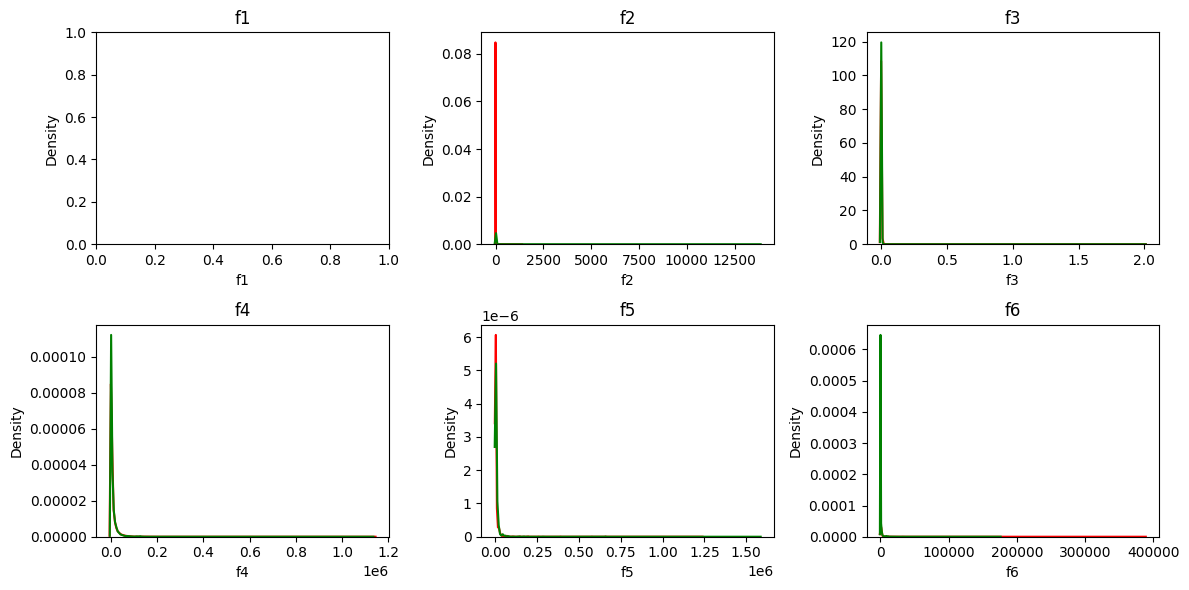

In [16]:
fig, axes = plt.subplots(2,3, figsize=(12,6))
for i, col in enumerate(num_cols):
    ax = axes[i//3, i%3]
    for label, color in [(0,'red'), (1,'green')]:
        sns.kdeplot(data=df[df['label']==label], x=col, ax=ax, color=color, label='Позитив' if label else 'Негатив')
    ax.set_title(col)
plt.tight_layout()
plt.show()

Все распределения практически идентичны – никакой разделяющей способности.

Оставляем только нужные атрибуты - текст и тональность.

In [17]:
final_df = df[['text', 'label']].copy()

final_df['text'] = final_df['text'].astype(str) # приводим текст к строковому виду
final_df = final_df[final_df['text'].str.strip() != ''] # удаляем пустые строки

final_df = final_df.drop_duplicates() # удаляем дубликаты

### Итоговая структура набора данных

In [18]:
final_df.shape

(217440, 2)

В наборе данных теперь 217 тысяч записей и два атрибута.

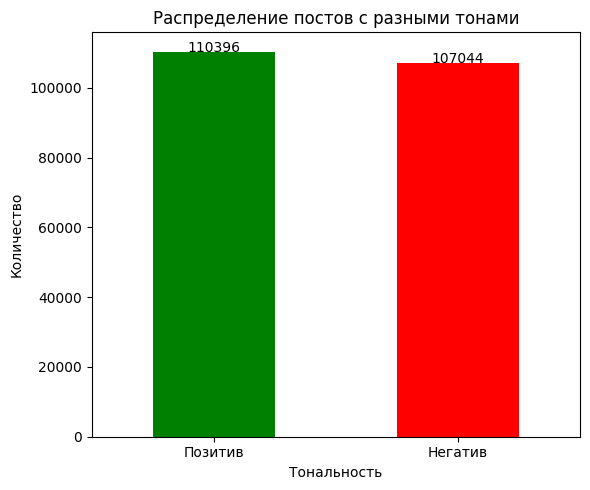

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
final_df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение постов с разными тонами')
plt.xlabel('Тональность')
plt.ylabel('Количество')
plt.xticks([0,1], ['Позитив', 'Негатив'], rotation=0)
for i, v in enumerate(final_df['label'].value_counts().values):
    plt.text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()

Как можно увидеть количество постов с разными тонами практически равное с небольшим перевесом позитивных.

Пример того, какие данные теперь в датасете:

In [23]:
final_df.sample(5)

,text,label
189628,@larusha_mr я вот думаю с завтрашнего дня нача...,0
77105,RT @iEgoisme: @PRroom Я завидую!;) Я в своё вр...,1
213897,@Dobyszew @alimansarov Её зависть к соседу муч...,0
53991,@DarikShumilin @DallonUrie ахахаах ты звук вме...,1
73742,Кайф! Офис освещается только светом из окна! Д...,1


# 2. Проведение предварительной обработки текстов размеченного датасета

- Провести очистку данных: удалить стоп-слова, специальные символы и лишние пробелы.
- Привести весь текст к нижнему регистру.
- Выполнить лемматизацию (или стемминг) текстов.

### Добавим нужные библиотеки для этого этапа:

In [24]:
import re
import string
import nltk
from nltk.corpus import stopwords
import pymorphy3

Загрузим русские стоп-слова:

In [18]:
nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')

# Дополнительно добавим несколько частых слов, не несущих смысла
extra_stopwords = ['это', 'так', 'вот', 'быть', 'как', 'для', 'на', 'с', 'по', 'к', 'у', 'же', 'ли', 'бы', 'да', 'нет']
russian_stopwords.extend(extra_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Рустам\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Инициализируем лемматизатор для русского языка

In [19]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

Создадим функцию для предобработки текста.

In [ ]:
def preprocess_text(text: str) -> str:
    # 1. Нижний регистр
    text = text.lower()
    
    # 2. Удаление пунктуации, цифр, спецсимволов (оставляем только кириллицу и пробелы)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    
    # 3. Токенизация
    tokens = text.split()
    
    # 4. Удаление стоп-слов и лемматизация
    cleaned_tokens = []
    for token in tokens:
        if token not in russian_stopwords:
            lemma = morph.parse(token)[0].normal_form
            cleaned_tokens.append(lemma)
    
    # 5. Сборка обратно в строку
    return ' '.join(cleaned_tokens)

Применим функцию для нашего атрибута text в датасете.

In [21]:
final_df['clean_text'] = final_df['text'].apply(preprocess_text)

In [22]:
final_df.sample(5)

,text,label,clean_text
138869,@romancefrommars бедный телефон скоро сдохнет(,0,бедный телефон скоро сдохнуть
189271,И все это мне нельзя ( http://t.co/OORKx0OacC,0,
137230,"чтобы нормально посмотреть телик,надо ещё где-...",0,нормально посмотреть телик ещё день подождать
174792,@Shchepil_OFF я думала.я одна умудрилась забол...,0,думать один умудриться заболеть нг
157800,@HollyDniwe у меня просто зачеты поставили + о...,0,просто зачёт поставить обычный пара пара день ...


**Результат**: мы получили новую колонку clean_text с предобработанными текстами, которые можно использовать для дальнейшего анализа и моделирования.

# 3. Тематическое моделирование

#### Цель текущего этапа: Провести тематическое моделирование для анализа положительных и отрицательных постов.

Что нужно сделать:

- Выявить слова, характерные для каждого класса (позитив / негатив).
- Построить облака слов для наглядного представления специфической лексики.
- Применить модели тематического моделирования для определения ключевых тем внутри каждого класса.

In [ ]:
from wordcloud import WordCloud, STOPWORDS

Мы объединяли два датасета для обработки и очисти. Теперь же для анализа и обучения нам нужно его снова разъединить по признаку тональности.

In [24]:
df_pos = final_df[final_df['label'] == 1].copy()
df_neg = final_df[final_df['label'] == 0].copy()

### Функция для построения облака слов

In [ ]:
def plot_wordcloud(text_series, title, colormap='viridis'):
    # Объединяем все тексты в одну строку
    text = ' '.join(text_series.astype(str))
    
    # Создаём облако слов
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap=colormap,
        max_words=100,
        stopwords=set(russian_stopwords),
        random_state=42
    ).generate(text)
    
    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    return wordcloud

### Визуализация облаков слов для каждого класса

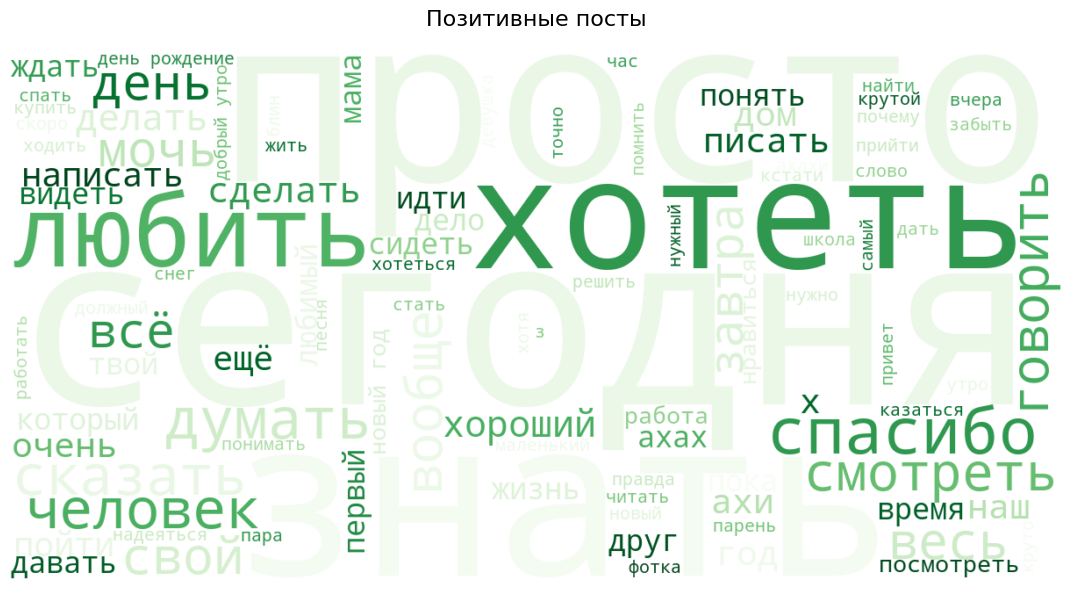

In [26]:
plot_wordcloud(df_pos['clean_text'], 'Позитивные посты', colormap='Greens')
plt.show()

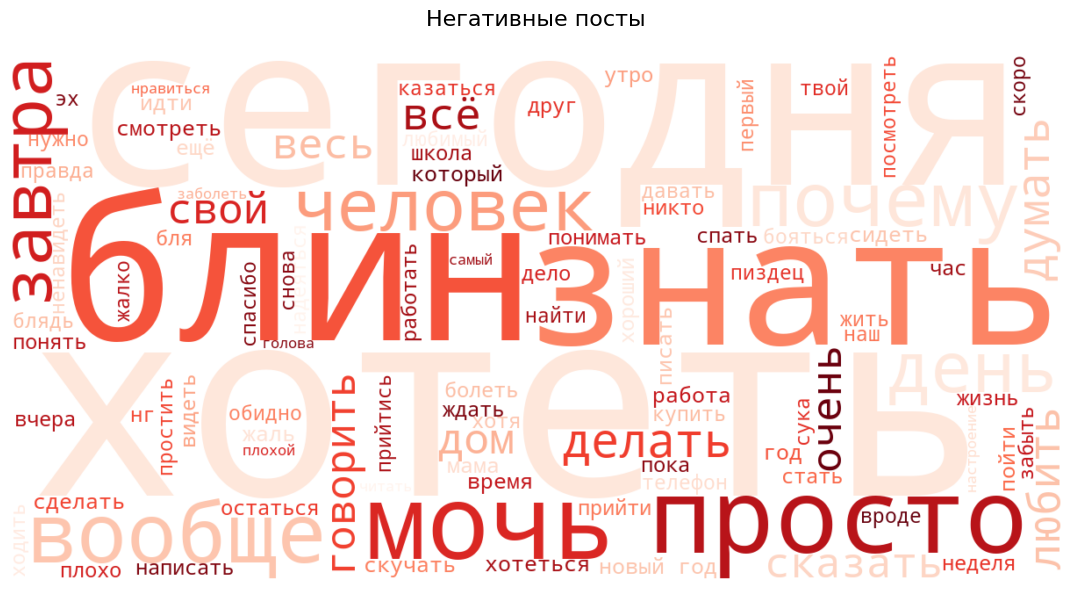

In [27]:
plot_wordcloud(df_neg['clean_text'], 'Негативные посты', colormap='Reds')
plt.show()

### Частотный анализ — специфичные слова для каждого класса

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
def get_top_words(text_series, n_top=20, min_df=2, max_df=0.8):
    vectorizer = CountVectorizer(
        min_df=min_df, 
        max_df=max_df,
        max_features=1000
    )
    X = vectorizer.fit_transform(text_series.astype(str))
    
    word_freq = X.sum(axis=0).A1
    feature_names = vectorizer.get_feature_names_out()
    
    freq_df = pd.DataFrame({
        'word': feature_names,
        'frequency': word_freq
    }).sort_values('frequency', ascending=False)
    
    return freq_df.head(n_top)

Пример позитивных слов

In [30]:
top_pos = get_top_words(df_pos['clean_text'])
print(top_pos.to_string(index=False))

    word  frequency
    день       5267
      ты       4510
 сегодня       4362
   такой       4338
    быть       4276
  просто       3701
 спасибо       3578
  хотеть       3574
     мой       3539
   знать       3504
   очень       3369
    весь       3276
  любить       3269
 хороший       3042
     год       2993
 человек       2815
   новый       2648
    свой       2617
смотреть       2375
     всё       2297


Пример негативных слов

In [31]:
top_neg = get_top_words(df_neg['clean_text'])
print(top_neg.to_string(index=False))

   word  frequency
 хотеть       7820
   день       5113
сегодня       4219
  такой       4201
   мочь       4021
  очень       3914
    год       3555
  знать       3262
    мой       3255
   быть       3241
 завтра       3183
   блин       3148
 просто       2900
человек       2865
 почему       2835
 вообще       2817
 делать       2494
   один       2444
     ты       2443
  новый       2423


### Сравнительный анализ слов (TF-IDF подход)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
def get_class_specific_words(df_pos, df_neg, n_top=15):
    df_combined = pd.concat([
        df_pos[['clean_text']].assign(label='pos'),
        df_neg[['clean_text']].assign(label='neg')
    ], ignore_index=True)
    
    tfidf = TfidfVectorizer(
        max_features=1000,
        min_df=3,
        max_df=0.7,
        ngram_range=(1, 2)
    )
    
    texts_pos = df_pos['clean_text'].astype(str).tolist()
    texts_neg = df_neg['clean_text'].astype(str).tolist()
    
    tfidf.fit(df_combined['clean_text'].astype(str))
    
    def get_mean_tfidf(texts):
        if not texts:
            return None
        X = tfidf.transform(texts)
        return X.mean(axis=0).A1
    
    mean_pos = get_mean_tfidf(texts_pos)
    mean_neg = get_mean_tfidf(texts_neg)
    
    feature_names = tfidf.get_feature_names_out()
    
    # Разница в весах: положительные значения = слова для позитива
    diff = mean_pos - mean_neg if mean_pos is not None and mean_neg is not None else None
    
    if diff is not None:
        spec_df = pd.DataFrame({
            'word': feature_names,
            'pos_weight': mean_pos,
            'neg_weight': mean_neg,
            'diff': diff
        })
        
        spec_pos = spec_df.nlargest(n_top, 'diff')[['word', 'diff', 'pos_weight']]
        spec_neg = spec_df.nsmallest(n_top, 'diff')[['word', 'diff', 'neg_weight']]
        
        return spec_pos, spec_neg
    
    return None, None

In [34]:
spec_pos, spec_neg = get_class_specific_words(df_pos, df_neg)

Слова, характерные для ПОЗИТИВA

In [35]:
print(spec_pos.to_string(index=False))

    word     diff  pos_weight
 спасибо 0.011264    0.014262
      ты 0.006884    0.015526
 хороший 0.006048    0.010628
     ахи 0.005021    0.006289
    ахах 0.004684    0.005748
  добрый 0.004342    0.006194
  любить 0.004273    0.012217
   ахахи 0.003734    0.004435
  привет 0.003353    0.004828
    быть 0.003290    0.014175
 приятно 0.003182    0.003662
    весь 0.003072    0.010644
    твой 0.003064    0.006598
  просто 0.002935    0.012907
смотреть 0.002810    0.009152


Слова, характерные для НЕГАТИВА

In [36]:
print(spec_neg.to_string(index=False))

    word      diff  neg_weight
  хотеть -0.014670    0.025769
    блин -0.009542    0.012655
  почему -0.007376    0.011589
    мочь -0.006953    0.014349
  болеть -0.006660    0.008415
 скучать -0.005637    0.007289
    жаль -0.005169    0.006152
   плохо -0.004384    0.006144
  завтра -0.004288    0.011234
     бля -0.003690    0.005417
хотеться -0.003659    0.006458
   жалко -0.003535    0.004135
  обидно -0.003479    0.003724
  вообще -0.003348    0.010626
заболеть -0.003230    0.003667


### Тематическое моделирование через NMF

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [ ]:
def run_nmf_modeling(texts_series, class_name, n_topics=3):
    print(f"\nТЕМАТИЧЕСКОЕ МОДЕЛИРОВАНИЕ (NMF): {class_name}")
    print("=" * 60)

    tfidf_vectorizer = TfidfVectorizer(
        max_df=0.95,    
        min_df=2,        
        max_features=2000 
    )
    
    # Создаем матрицу документ-термин
    doc_term_matrix = tfidf_vectorizer.fit_transform(texts_series.astype(str))
    feature_names = tfidf_vectorizer.get_feature_names_out()

    nmf_model = NMF(
        n_components=n_topics, 
        random_state=42, 
        init='nndsvd',
        alpha_W=0.1, 
        alpha_H=0.1
    )
    
    nmf_model.fit(doc_term_matrix)

    for i, topic_weights in enumerate(nmf_model.components_):
        top_words_indices = topic_weights.argsort()[:-11:-1]
        
        top_words = [feature_names[i] for i in top_words_indices]
        
        print(f"Тема {i+1}: {', '.join(top_words)}")
    
    print("-" * 60)

In [39]:
run_nmf_modeling(df_pos['clean_text'], "ПОЗИТИВНЫЕ посты", n_topics=3)


ТЕМАТИЧЕСКОЕ МОДЕЛИРОВАНИЕ (NMF): ПОЗИТИВНЫЕ посты
Тема 1: день, ты, такой, быть, спасибо, любить, знать, сегодня, хороший, хотеть
Тема 2: спасибо, ты, день, хороший, любить, очень, быть, весь, такой, сегодня
Тема 3: день, сегодня, хороший, ты, рождение, весь, спасибо, добрый, быть, утро
------------------------------------------------------------


In [40]:
run_nmf_modeling(df_neg['clean_text'], "НЕГАТИВНЫЕ посты", n_topics=3)


ТЕМАТИЧЕСКОЕ МОДЕЛИРОВАНИЕ (NMF): НЕГАТИВНЫЕ посты
Тема 1: хотеть, день, спать, очень, сегодня, блин, завтра, такой, мочь, знать
Тема 2: хотеть, день, сегодня, год, очень, мочь, такой, быть, завтра, знать
Тема 3: такой, хотеть, знать, почему, мочь, день, очень, блин, сегодня, человек
------------------------------------------------------------


In [ ]:
def plot_word_frequency_comparison(df_pos, df_neg, n_words=15):
    top_pos = get_top_words(df_pos['clean_text'], n_top=50)
    top_neg = get_top_words(df_neg['clean_text'], n_top=50)
    
    common_words = set(top_pos['word']) & set(top_neg['word'])
    if len(common_words) < n_words:
        compare_words = list(set(list(top_pos['word'].head(n_words)) + 
                                list(top_neg['word'].head(n_words))))[:n_words]
    else:
        compare_words = list(common_words)[:n_words]
    
    pos_freq = top_pos[top_pos['word'].isin(compare_words)].set_index('word')['frequency']
    neg_freq = top_neg[top_neg['word'].isin(compare_words)].set_index('word')['frequency']
    
    comp_df = pd.DataFrame({
        'positive': pos_freq,
        'negative': neg_freq
    }).fillna(0)
    
    plt.figure(figsize=(14, 6))
    x = range(len(comp_df))
    width = 0.35
    
    plt.bar([i - width/2 for i in x], comp_df['positive'], 
            width, label='Позитив', color='lightgreen', edgecolor='green')
    plt.bar([i + width/2 for i in x], comp_df['negative'], 
            width, label='Негатив', color='lightcoral', edgecolor='red')
    
    plt.xticks(x, comp_df.index, rotation=45, ha='right')
    plt.xlabel('Слова')
    plt.ylabel('Частота')
    plt.title('Сравнение частоты слов в позитивных и негативных постах')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return comp_df

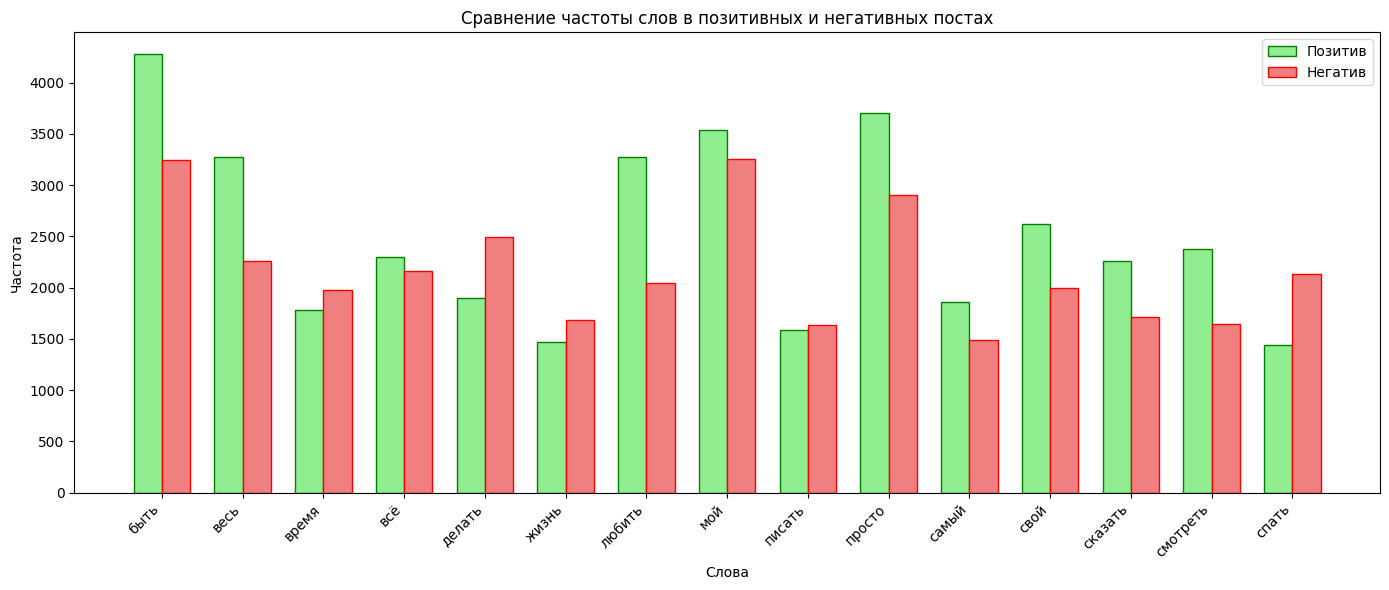

In [42]:
comp_result = plot_word_frequency_comparison(df_pos, df_neg)

# 4. Векторизация

На данном этапе нужно получить векторные представления текстов.



In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X = final_df['clean_text']
y = final_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,    
    ngram_range=(1, 2),   
    min_df=3,      
    max_df=0.85,  
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 5. Классификация.

- Обучить классификатор на полученных векторах.
- Рассмотреть не менее 3 моделей классификации.
- Провести оценку качества моделей.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [49]:
results = {}

In [ ]:
for name, model in models.items():
    print(f"\nОбучение модели: {name}")
    
    model.fit(X_train_tfidf, y_train)
    
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Негатив', 'Позитив'])
    
    print(f"Accuracy: {acc:.4f}")
    print(report)
    print("-" * 40)
    
    results[name] = {
        'model': model,
        'accuracy': acc,
        'report': report,
        'predictions': y_pred
    }


Обучение модели: Logistic Regression
Accuracy: 0.7126
              precision    recall  f1-score   support

     Негатив       0.72      0.68      0.70     21409
     Позитив       0.71      0.74      0.72     22079

    accuracy                           0.71     43488
   macro avg       0.71      0.71      0.71     43488
weighted avg       0.71      0.71      0.71     43488

----------------------------------------

Обучение модели: Linear SVC
Accuracy: 0.7086
              precision    recall  f1-score   support

     Негатив       0.71      0.69      0.70     21409
     Позитив       0.71      0.73      0.72     22079

    accuracy                           0.71     43488
   macro avg       0.71      0.71      0.71     43488
weighted avg       0.71      0.71      0.71     43488

----------------------------------------

Обучение модели: Random Forest
Accuracy: 0.7018
              precision    recall  f1-score   support

     Негатив       0.70      0.70      0.70     21409
     

In [51]:
print("Сравнение моделей:\n")
for name, res in results.items():
    print(f"{name}: {res['accuracy']:.4f}")

Сравнение моделей:

Logistic Regression: 0.7126
Linear SVC: 0.7086
Random Forest: 0.7018


Сохраним лучшую модель

In [52]:
import pickle

In [53]:
logistic_model = models["Logistic Regression"]

In [54]:
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(logistic_model, f)

Также сохраним vectorizer для будущего преобразования нового текста

In [55]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# 6. Парсинг данных и итеративное дообучение модели

- Собрать с сайта не менее 500 пользовательских комментариев (парсинг текстовых данных).
- Классифицировать собранные комментарии текущей обученной моделью.
- Проанализировать корректность работы модели
- Отобрать из выборки комментарии, по которым модель уверена (вероятность >0.8 или <0.2), и добавить их в размеченный корпус.
- Выполнить векторизацию и переобучение модели на обновлённом корпусе.
- Из спарсенных данных удалить добавленные в корпус тексты.
- Выполнить прогноз по оставшейся выборке.
- Повторить процесс несколько раз.

# Импортируем библиотеки и создаем метод для парсинга

In [112]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from youtube_comment_downloader import YoutubeCommentDownloader

def get_youtube_comments(video_url, max_comments=600):
    downloader = YoutubeCommentDownloader()
    comments = []
    try:
        print(f"Парсинг комментариев с {video_url}...")
        for comment in downloader.get_comments_from_url(video_url):
            comments.append(comment['text'])
            if len(comments) >= max_comments:
                break
    except Exception as e:
        print(f"Ошибка: {e}")
    print(f"Спаршено {len(comments)} комментариев.")
    return comments

Выбираем видео с ютуба для парсинга и берем его ссылку, ставим ограничение на 600 комментариев

In [113]:
video_url = "https://www.youtube.com/watch?v=_X2Lj3O2Sv0"
scraped_texts = get_youtube_comments(video_url, max_comments=600)
scraped_processed = [preprocess_text(str(txt)) for txt in scraped_texts if str(txt).strip()]

Парсинг комментариев с https://www.youtube.com/watch?v=_X2Lj3O2Sv0...
Спаршено 600 комментариев.


# Загрузка модели

In [114]:
with open('logistic_regression_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Обучение

In [115]:
def iterative_training(model, vectorizer, new_texts, initial_df, n_iterations=3):
    current_df = initial_df[['clean_text', 'label']].copy()
    remaining_texts = new_texts.copy()
    all_added = []
    
    for iteration in range(n_iterations):
        print(f"\n итерация {iteration+1} ")
        print(f"Осталось текстов: {len(remaining_texts)}")
        
        if not remaining_texts:
            break
        
        X_new = vectorizer.transform(remaining_texts)
        probs = model.predict_proba(X_new)
        predictions = model.predict(X_new)
        max_probs = np.max(probs, axis=1)
        
        confident_idx = [i for i, p in enumerate(max_probs) if p >= 0.8 or p <= 0.2]
        
        if not confident_idx:
            print("Нет уверенных прогнозов. Останавливаем.")
            break
        
        new_data = pd.DataFrame({
            'clean_text': [remaining_texts[i] for i in confident_idx],
            'label': [predictions[i] for i in confident_idx]
        })
        current_df = pd.concat([current_df, new_data], ignore_index=True)
        all_added.extend([(remaining_texts[i], predictions[i]) for i in confident_idx])
        
        remaining_texts = [t for i, t in enumerate(remaining_texts) if i not in confident_idx]
        
        print(f"Добавлено: {len(new_data)} текстов")
        print(f"Положительных: {sum(new_data['label'])}")
        print(f"Отрицательных: {len(new_data) - sum(new_data['label'])}")
        
        X_full = vectorizer.transform(current_df['clean_text'])
        model.fit(X_full, current_df['label'])
    
    return model, current_df, remaining_texts, all_added

Запуск обучения 

In [116]:
print("запуск дообучения")

final_model, updated_df, remaining_unlabeled, added_history = iterative_training(
    model, vectorizer, scraped_processed, final_df, n_iterations=3
)

запуск дообучения

 итерация 1 
Осталось текстов: 600
Добавлено: 57 текстов
Положительных: 43
Отрицательных: 14

 итерация 2 
Осталось текстов: 543
Добавлено: 7 текстов
Положительных: 5
Отрицательных: 2

 итерация 3 
Осталось текстов: 536
Добавлено: 2 текстов
Положительных: 2
Отрицательных: 0


# Сохранение модели и векторизатора

In [117]:
with open('logistic_regression_model_final.pkl', 'wb') as f:
    pickle.dump(final_model, f)
with open('tfidf_vectorizer_final.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Итоги

In [118]:
print("Итоговая статистика")

total_scraped = len(scraped_texts)
added_count = len(updated_df) - len(final_df)
added_pos = sum(1 for _, label in added_history if label == 1)
added_neg = sum(1 for _, label in added_history if label == 0)

print(f"\n Всего спаршено: {total_scraped}")
print(f"Добавлено в датасет: {added_count}")
print(f"Положительных: {added_pos}")
print(f"Отрицательных: {added_neg}")
print(f"Осталось неразмеченных: {len(remaining_unlabeled)}")
print(f"\n Итоговый датасет: {len(updated_df)} записей")
print(f"Положительных: {(updated_df['label'] == 1).sum()}")
print(f"Отрицательных: {(updated_df['label'] == 0).sum()}")
print(f"Точность на тесте: {accuracy_score(y_test, final_model.predict(X_test_tfidf)):.4f}")

Итоговая статистика

 Всего спаршено: 600
Добавлено в датасет: 66
Положительных: 50
Отрицательных: 16
Осталось неразмеченных: 534

 Итоговый датасет: 217506 записей
Положительных: 110446
Отрицательных: 107060
Точность на тесте: 0.7388


In [119]:
X_scraped = vectorizer.transform(scraped_processed)
all_pred = final_model.predict(X_scraped)
all_probs = np.max(final_model.predict_proba(X_scraped), axis=1)

positive = [(i+1, text, all_probs[i]) for i, text in enumerate(scraped_texts) if all_pred[i] == 1]
negative = [(i+1, text, all_probs[i]) for i, text in enumerate(scraped_texts) if all_pred[i] == 0]

print(f"\n Положительные (всего: {len(positive)}):")
for idx, text, conf in positive[:4] + positive[5:8]:
    print(f"   {idx}. [conf={conf:.3f}] {text[:100]}...")

print(f"\n Отрицательные (всего: {len(negative)}):")
for idx, text, conf in negative[:6] + negative[10:14]:
    print(f"   {idx}. [conf={conf:.3f}] {text[:100]}...")

print(" Финальная модель: logistic_regression_model_final.pkl")


 Положительные (всего: 307):
   1. [conf=0.725] 2:03 интересно чем крабс занимался в первые три года жизни...
   2. [conf=0.802] 5:24 я помню в какой то серии мистера Крабс когда попробовал крабсбургер он сказал "хммм вот какой я...
   3. [conf=0.776] Музыка на фоне просто кайф для ушей...
   5. [conf=0.658] Актуально...
   8. [conf=0.715] Тайный рецепт крабсбургера : булочка потом замороженная котлета ( веганская ) , сыр , Пикули , салат...
   9. [conf=0.928] 2:35 Слава Богу НАШ🙏❤СЛАВА Z🙏❤АНГЕЛА ХРАНИТЕЛЯ Z КАЖДОМУ ИЗ ВАС🙏❤БОЖЕ ХРАНИ Z🙏❤СПАСИБО ВАМ НАШИ СВО🙏...
   10. [conf=0.684] Детство......

 Отрицательные (всего: 293):
   4. [conf=0.508] Губка Боб ветеран войны страдающий от ПТСР:Губка Боб ветеран войны и я поясню почему, он встаёт в од...
   6. [conf=0.610] Голос с ощущением безопасности......
   12. [conf=0.501] кто из 2026?...
   18. [conf=0.799] Господи какая ностальгия 😢😢...
   20. [conf=0.579] Кто из 1899 года?...
   21. [conf=0.550] Оправдал ник...
   28. [conf=0.837] Шел

# Сохраняем датасет

In [120]:
updated_df.to_csv('final_dataset_full.csv', index=False, encoding='utf-8-sig')
print(f"Сохранен полный датасет: {len(updated_df)} записей")


Сохранен полный датасет: 217506 записей
